## 1. package import 

In [1]:
from zipline import run_algorithm
from zipline.api import order_target_percent, record, symbol
from datetime import datetime
import pytz

import pandas as pd

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
import warnings

pio.templates.default = "ggplot2"
warnings.filterwarnings('ignore')

## 2. func

- 다우존스 구성 종목 30개를 100일 이동 평균을 확인한다.
- 가격이 이동 평균 위라면, 1/30(약 3.33%)의 배분으로 롱 포지션을 취한다. 
- 완벽한 강세장에서 30개 종목 모두 각자의 평균을 상회할 경우 전체 포트폴리오의 노출도가 100%가 되지만 대부분 그 이하가 될 수 있다.


In [2]:
def initialize(context):
        dji = [
        "AAPL",
        "AXP",
        "BA",
        "CAT",
        "CSCO",
        "CVX",
        "DIS",
        "DWDP",
        "GS",
        "HD",
        "IBM",
        "INTC",
        "JNJ",
        "JPM",
        "KO",
        "MCD",
        "MMM",
        "MRK",
        "MSFT",
        "NKE",
        "PFE",
        "PG",
        "TRV",
        "UNH",
        "UTX",
        "V",
        "VZ",
        "WBA",
        "WMT",
        "XOM",  ]
        context.dji_symbols = [symbol(s) for s in dji]
        context.index_average_window = 100

In [3]:
def handle_data(context, data):
    stock_hist = data.history(context.dji_symbols,"close", context.index_average_window, "1d")
    stock_analtics = pd.DataFrame()
    stock_analtics['above_mean'] = stock_hist.iloc[-1] > stock_hist.mean()
    stock_analtics.loc[stock_analtics['above_mean'] == True, 'weight'] = 1/len(context.dji_symbols)
    stock_analtics.loc[stock_analtics['above_mean'] == False, 'weight'] = 0.0
    
    for stock, analitics in stock_analtics.iterrows():
        if data.can_trade(stock):
            order_target_percent(stock, analitics['weight'])
        

In [4]:
def analyze(context, perf):
    legendStyle=dict(orientation="h",yanchor="bottom", y=1.02,xanchor="right",x=1)
    lineStyle_01=dict(width=1.0)
    lineStyle_03=dict(width=1.0)
    
    fig = make_subplots(rows=3, cols=1)
    fig.add_trace(go.Scatter(x=perf.index, y=perf['portfolio_value'], mode="lines", name="Equity Curve", line=lineStyle_03),  row=1, col=1)
    fig.add_trace(go.Scatter(x=perf.index, y=perf['gross_leverage'],  mode="lines", name="Exposure", line=lineStyle_01), row=2, col=1)
    fig.add_trace(go.Scatter(x=perf.index, y=perf['returns'],  mode="lines", name="Returns", line=lineStyle_01), row=3, col=1)
    
    fig.update_xaxes(showgrid=False, row=1, col=1)
    fig.update_layout(height=1200, width=800, title="Strategy Results", legend=legendStyle)
    fig.show()

## 3. Run

- 이 테스트에 사용한 종목은 테스트 기간동안 이미 생존한; 생존 편향된 종목이다.
- 이 강력한 전제 조건을 명심해야 한다.

![zipline_portfolio_backtest.png](./zipline_portfolio_backtest.png)

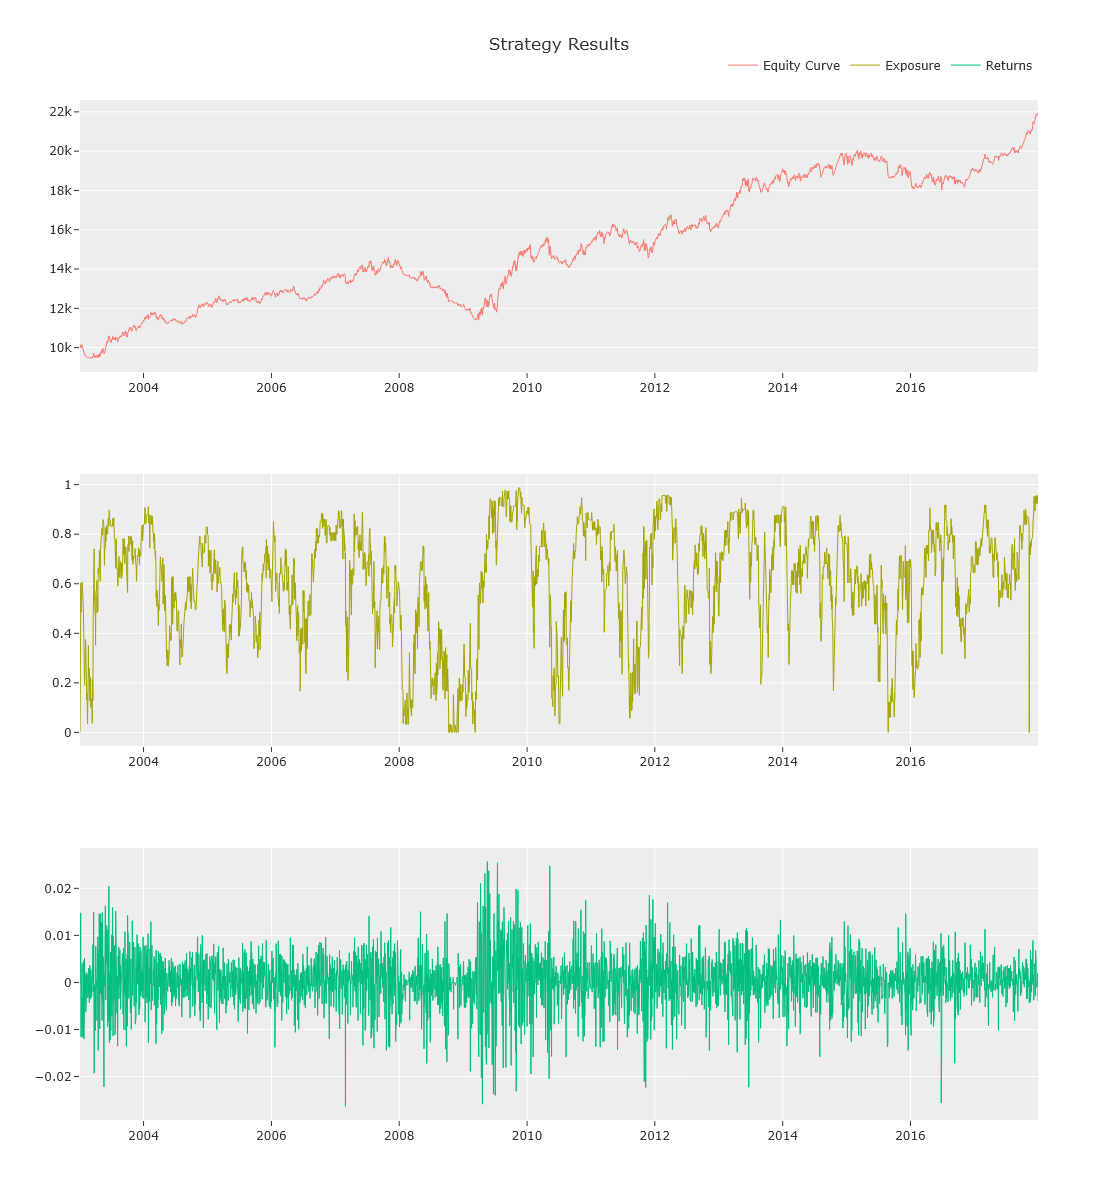

In [5]:
# Set start and end date
# start_date = datetime(1996, 1, 1, tzinfo=pytz.utc)
# end_date = datetime(2018, 12, 31, tzinfo=pytz.UTC)
start_date = pd.Timestamp('2003-1-1')
end_date = pd.Timestamp('2017-12-31')

# Fire off the backtest
results = run_algorithm(
    start=start_date,
    end=end_date, 
    initialize=initialize, 
    analyze=analyze, 
    handle_data=handle_data, 
    capital_base=10000, 
    data_frequency = 'daily', bundle='quandl' 
) 


---